![Penguins](../images/penguins_species.png)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as penguins.csv

Origin of this data : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

The dataset consists of 5 columns.

| Column | Description |
| :--- | :--- |
| culmen_length_mm | culmen length (mm) |
| culmen_depth_mm | culmen depth (mm) |
| flipper_length_mm | flipper length (mm) |
| body_mass_g | body mass (g) |
| sex | penguin sex |

Unfortunately, they have not been able to record the species of penguin, but they know that there are at least three species that are native to the region: Adelie, Chinstrap, and Gentoo. Your task is to apply your data science skills to help them identify groups in the dataset!

Importing the required Libraries for the setup.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import resample

from scipy.stats import f_oneway
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for professional plots
sns.set_theme(style="whitegrid", palette="muted")

Getting the data ready for analysis

In [2]:
print("Loading and cleaning data...")
penguins_df = pd.read_csv("../data/penguins.csv")

# Ensure numeric columns are strictly numeric (forces errors to NaN)
numeric_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in numeric_cols:
    penguins_df[col] = pd.to_numeric(penguins_df[col], errors='coerce')

# Drop missing values to ensure algorithms don't crash
penguins_df = penguins_df.dropna().reset_index(drop=True)

Loading and cleaning data...


Exploring the data by visualisation - Exploratory Data Analysis (EDA)

Generating Exploratory Data Analysis (EDA) plots...


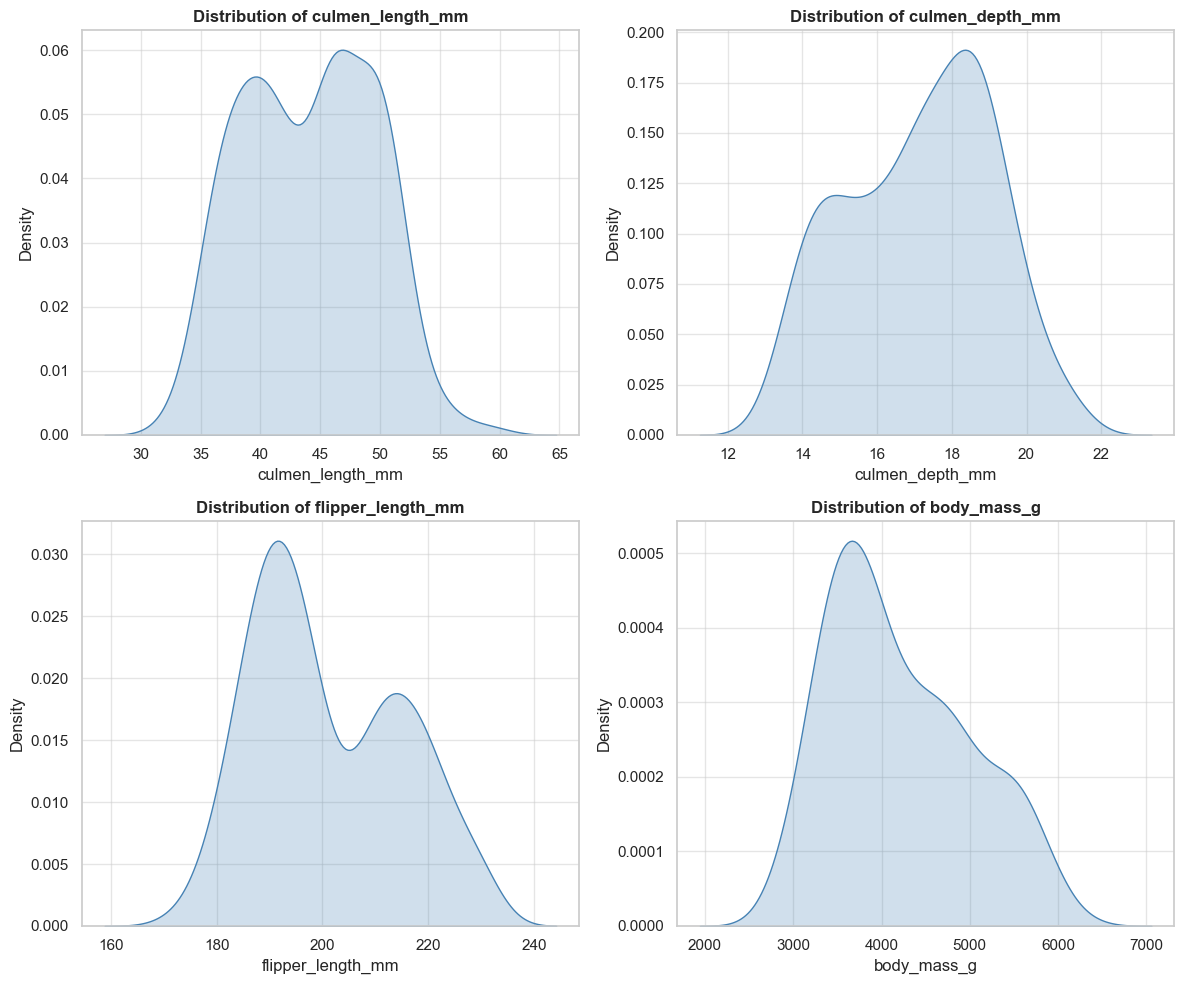

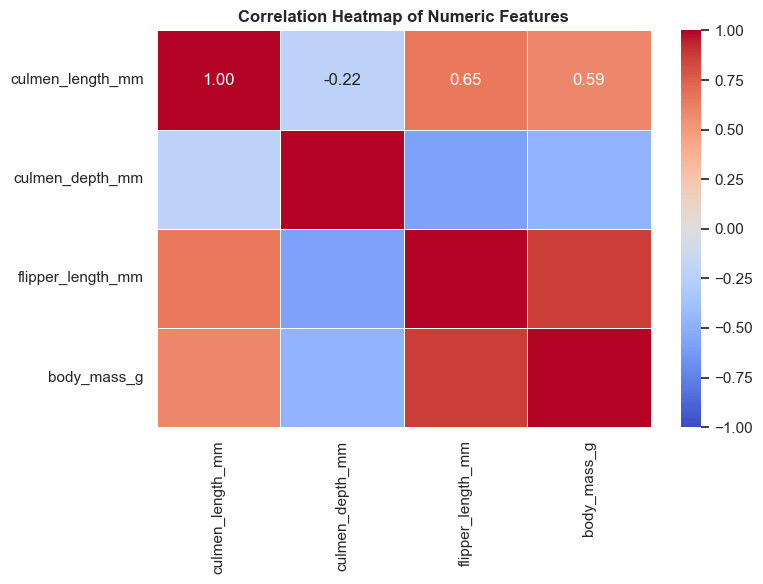

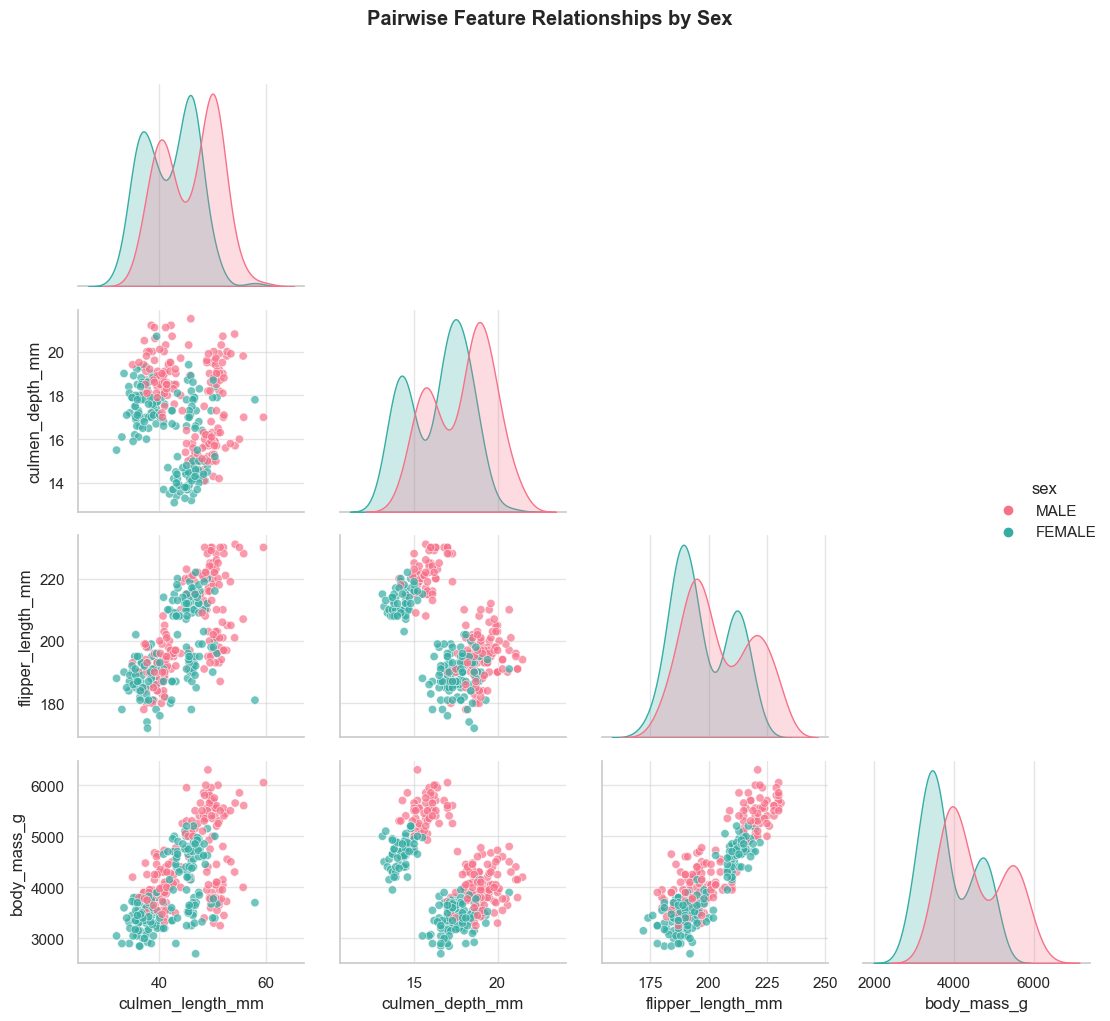

In [3]:
print("Generating Exploratory Data Analysis (EDA) plots...")

# 3.1: Distribution plots for numeric columns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=penguins_df, x=col, fill=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/penguins_distributions.png', bbox_inches='tight', dpi=300)
plt.show()

# 3.2: Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = penguins_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/penguins_correlation.png', bbox_inches='tight', dpi=300)
plt.show()

# 3.3: Pairwise Feature Relationship by Sex
sns.pairplot(penguins_df, vars=numeric_cols, hue='sex', corner=True, palette='husl', plot_kws={'alpha':0.7})
plt.suptitle('Pairwise Feature Relationships by Sex', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/penguins_pairplot.png', bbox_inches='tight', dpi=300)
plt.show()


Data Processing - using One Hot Encoding on the 'sex' column and Scaling the data for clustering

In [4]:
# Convert categorical variable ('sex') into dummy variables
penguins_dummies = pd.get_dummies(penguins_df, drop_first=True, dtype='int')

# Standard Scaling (critical for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(penguins_dummies)

Dimensionality Reduction - using PCA and t-SNE methods for reducing the dimensionaly of the data

In [5]:
# Calculate projections to be used in visualizations later
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_features = tsne.fit_transform(X_scaled)

Heirarchial Clustering - Visualizing the species using the Dendogram

Generating Dendrogram...


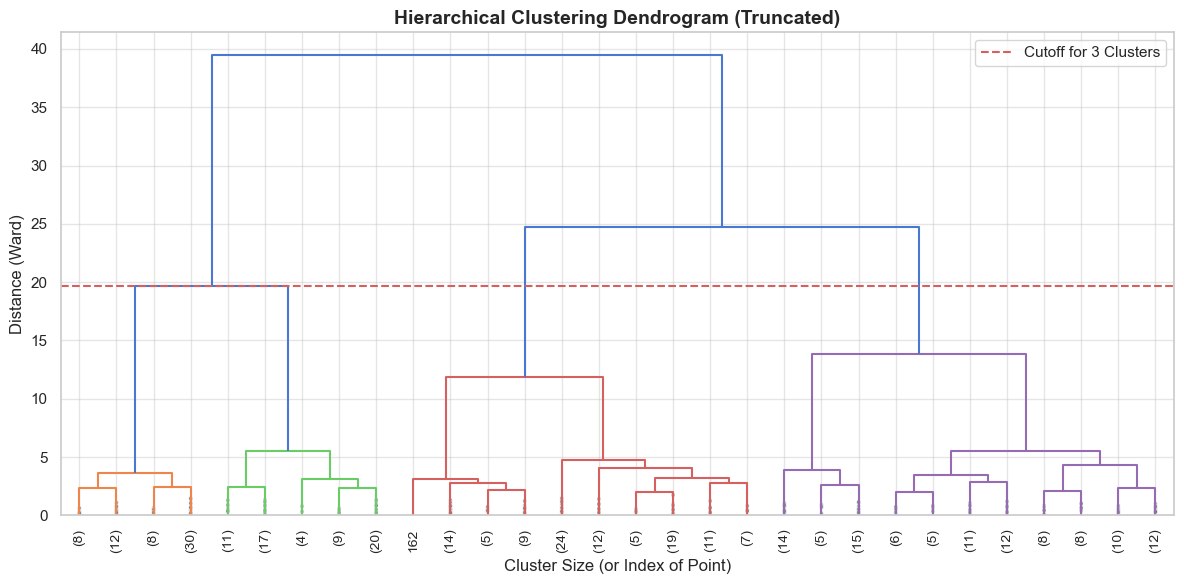

In [6]:
print("Generating Dendrogram...")
plt.figure(figsize=(12, 6))
plt.title('Hierarchical Clustering Dendrogram (Truncated)', fontsize=14, fontweight='bold')

Z = linkage(X_scaled, method='ward')

dendrogram(
    Z,
    truncate_mode='lastp', p=30,
    leaf_rotation=90., leaf_font_size=10.,
    show_contracted=True,
    color_threshold=Z[-3, 2] # Color split for 3 main clusters
)

plt.xlabel("Cluster Size (or Index of Point)", fontsize=12)
plt.ylabel("Distance (Ward)", fontsize=12)
plt.axhline(y=Z[-3, 2], color='r', linestyle='--', label='Cutoff for 3 Clusters')
plt.legend()
plt.tight_layout()
plt.savefig('../images/penguins_dendrogram.png', bbox_inches='tight', dpi=300)
plt.show()

Evaluation of Clusters based on different cluster sizes and using different metrics

Evaluating optimal K...


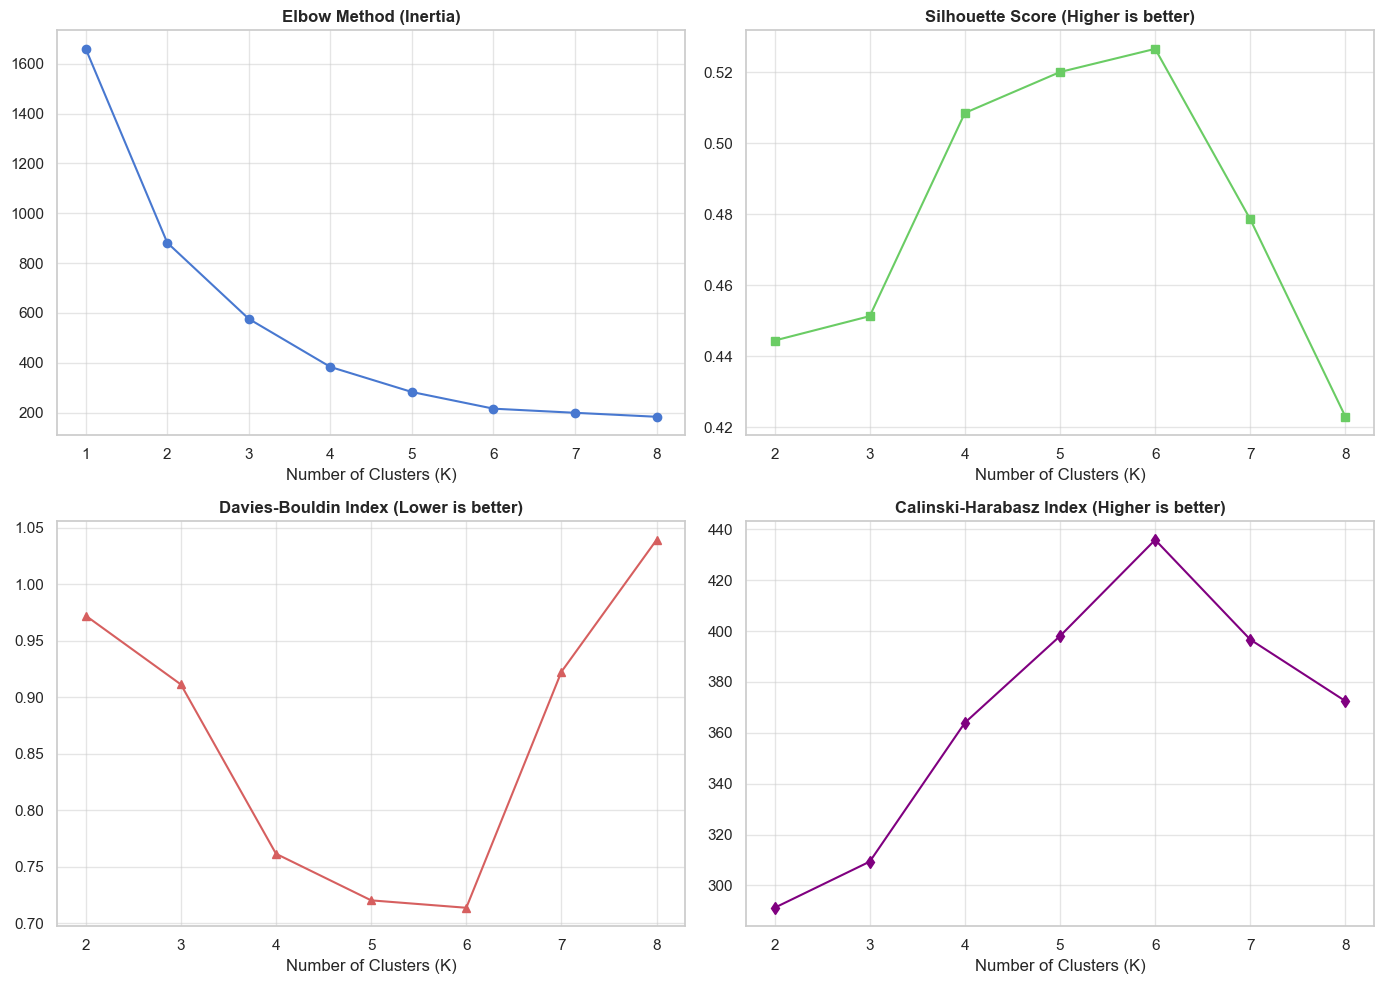

In [7]:
print("Evaluating optimal K...")
K_range = range(2, 9)
inertia_all = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in range(1, 9)]
sil_scores, db_scores, ch_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    db_scores.append(davies_bouldin_score(X_scaled, km.labels_))
    ch_scores.append(calinski_harabasz_score(X_scaled, km.labels_))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(range(1, 9), inertia_all, marker='o', color='b')
axes[0, 0].set_title('Elbow Method (Inertia)', fontweight='bold')

axes[0, 1].plot(K_range, sil_scores, marker='s', color='g')
axes[0, 1].set_title('Silhouette Score (Higher is better)', fontweight='bold')

axes[1, 0].plot(K_range, db_scores, marker='^', color='r')
axes[1, 0].set_title('Davies-Bouldin Index (Lower is better)', fontweight='bold')

axes[1, 1].plot(K_range, ch_scores, marker='d', color='purple')
axes[1, 1].set_title('Calinski-Harabasz Index (Higher is better)', fontweight='bold')

for ax in axes.flatten():
    ax.set_xlabel('Number of Clusters (K)')
plt.tight_layout()
plt.savefig('../images/penguins_evaluation_metrics.png', bbox_inches='tight', dpi=300)
plt.show()

Although it may look like that choosing 6 as number of clusters is statistically better option, but a prior knowledge that there are 3 species of penguins trumps the statistical measures.

Model comparison and choosing the best model by dynamic scoring

Comparing and scoring clustering algorithms...


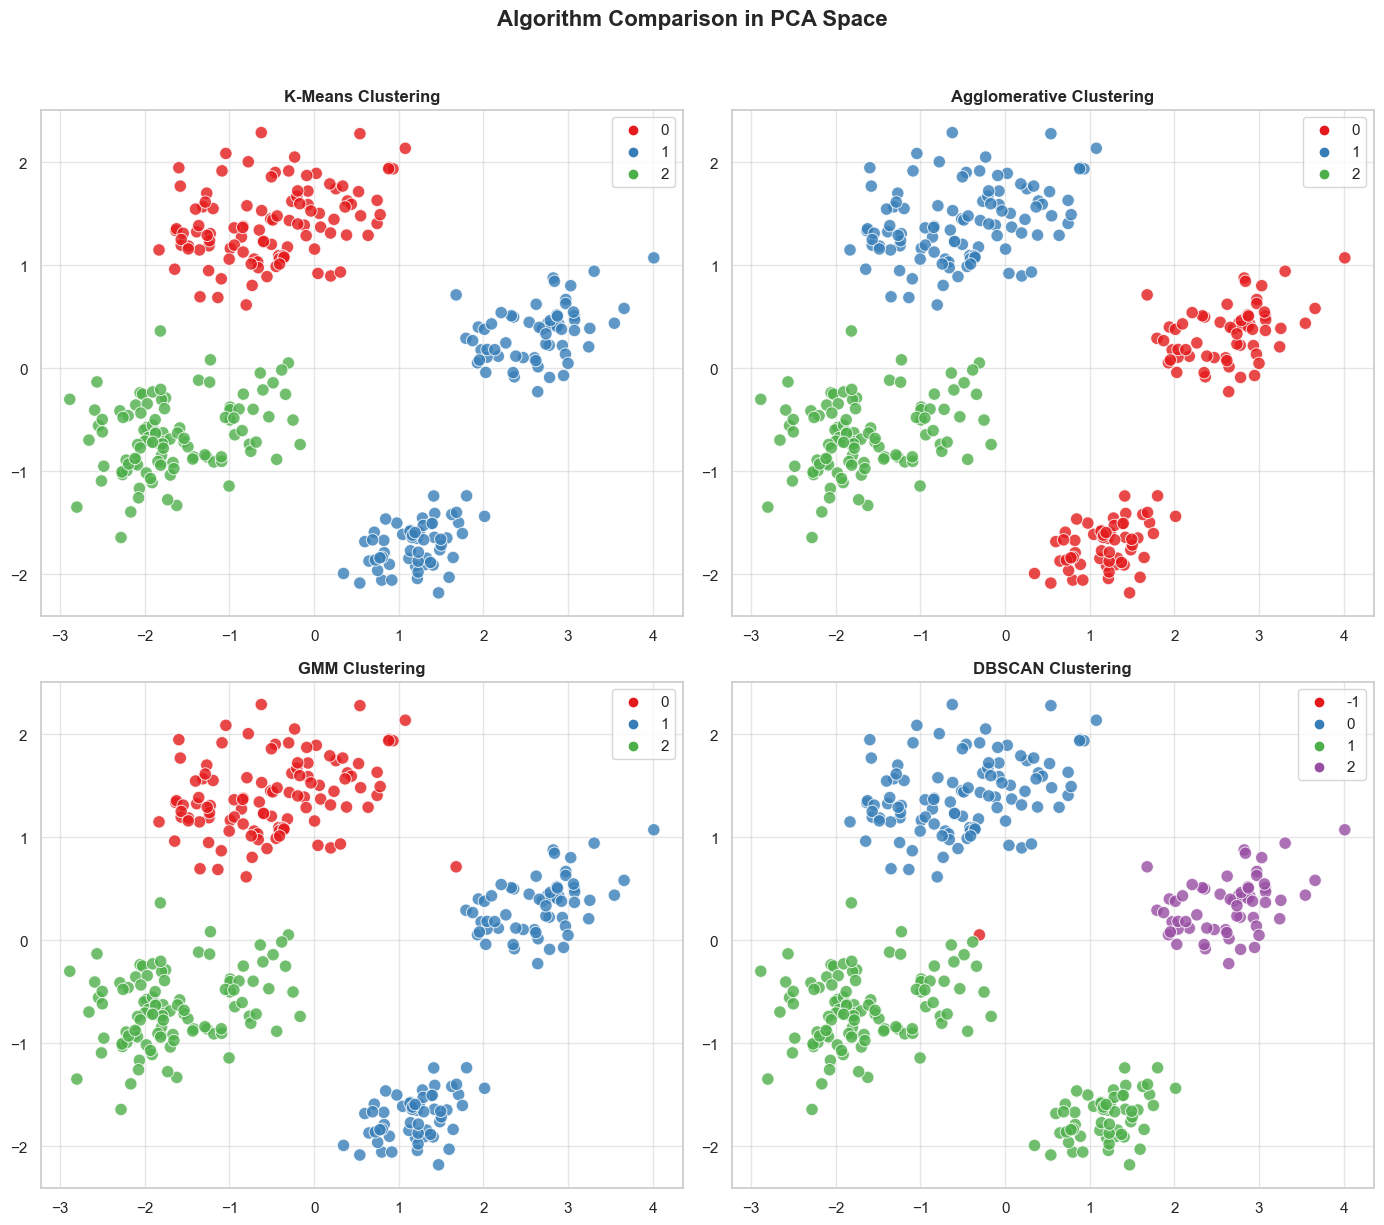


--- Model Scoring Leaderboard ---
               Silhouette  Davies-Bouldin  Calinski-Harabasz  Composite_Score
Model                                                                        
K-Means          0.451291        0.911211         309.358461         0.723858
Agglomerative    0.451291        0.911211         309.358461         0.723858
GMM              0.448994        0.915164         306.553374         0.652747
DBSCAN           0.359141        0.892127         142.618513         0.333333

WINNER: K-Means with a score of 0.72


In [13]:
print("Comparing and scoring clustering algorithms...")
n_clusters = 3

models = {
    "K-Means": KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=n_clusters),
    "GMM": GaussianMixture(n_components=n_clusters, random_state=42),
    "DBSCAN": DBSCAN(eps=1.5, min_samples=5)
}

results = []
trained_models = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    labels = model.fit_predict(X_scaled)
    trained_models[name] = model

    # Plotting
    sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=labels,
                    palette='Set1', ax=axes[i], s=80, alpha=0.8, legend='full')
    axes[i].set_title(f'{name} Clustering', fontweight='bold')

    # Metrics collection (handling DBSCAN noise/single cluster edge cases)
    unique_labels = np.unique(labels)
    if len(unique_labels) > 1 and not (len(unique_labels) == 2 and -1 in unique_labels):
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
    else:
        sil, db, ch = np.nan, np.nan, np.nan

    results.append({"Model": name, "Silhouette": sil, "Davies-Bouldin": db, "Calinski-Harabasz": ch})

plt.suptitle('Algorithm Comparison in PCA Space', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/penguins_model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

# 8.1 Create Composite Score
metrics_df = pd.DataFrame(results).set_index("Model")

# Min-Max Scaling for metrics (handling NaNs for failed models)
# Silhouette & CH: Higher is better -> (x - min) / (max - min)
scaled_sil = (metrics_df['Silhouette'] - metrics_df['Silhouette'].min()) / (metrics_df['Silhouette'].max() - metrics_df['Silhouette'].min())
scaled_ch = (metrics_df['Calinski-Harabasz'] - metrics_df['Calinski-Harabasz'].min()) / (metrics_df['Calinski-Harabasz'].max() - metrics_df['Calinski-Harabasz'].min())
# Davies-Bouldin: Lower is better -> (max - x) / (max - min)
scaled_db = (metrics_df['Davies-Bouldin'].max() - metrics_df['Davies-Bouldin']) / (metrics_df['Davies-Bouldin'].max() - metrics_df['Davies-Bouldin'].min())

# Calculate average score (0 to 1 scale) and fill NaNs with 0
metrics_df['Composite_Score'] = ((scaled_sil + scaled_ch + scaled_db) / 3).fillna(0)

print("\n--- Model Scoring Leaderboard ---")
print(metrics_df.sort_values(by="Composite_Score", ascending=False))

# Dynamically select the best model
best_model_name = metrics_df['Composite_Score'].idxmax()
best_model = trained_models[best_model_name]
print(f"\nWINNER: {best_model_name} with a score of {metrics_df.loc[best_model_name, 'Composite_Score']:.2f}")

Parameters of the best model visualized

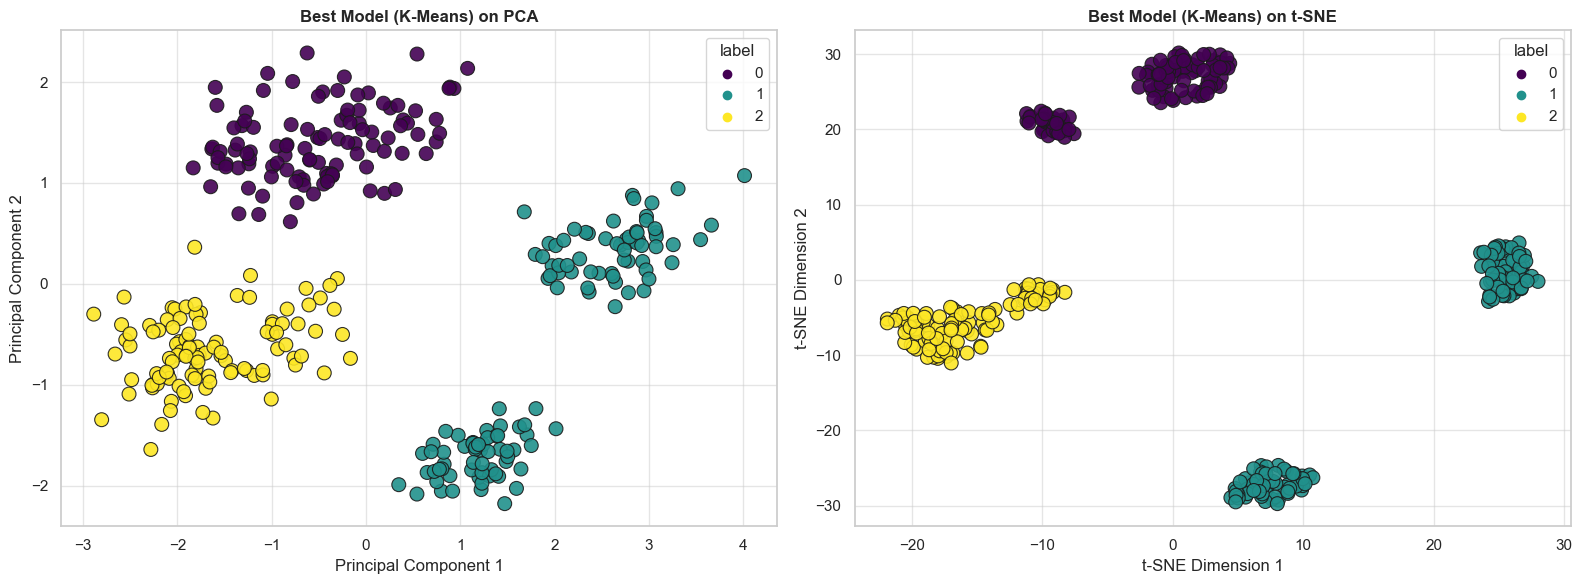

In [9]:
# Applying the chosen model (K-Means) to the original dataframe
best_kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(X_scaled)
penguins_df['label'] = best_kmeans.labels_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=penguins_df['label'],
                palette='viridis', ax=axes[0], s=100, alpha=0.9, edgecolor='k')
axes[0].set_title('Best Model (K-Means) on PCA', fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=tsne_features[:, 0], y=tsne_features[:, 1], hue=penguins_df['label'],
                palette='viridis', ax=axes[1], s=100, alpha=0.9, edgecolor='k')
axes[1].set_title('Best Model (K-Means) on t-SNE', fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.savefig('../images/penguins_best_model.png', bbox_inches='tight', dpi=300)
plt.show()

Cluster profiling and Feature importance illustrated

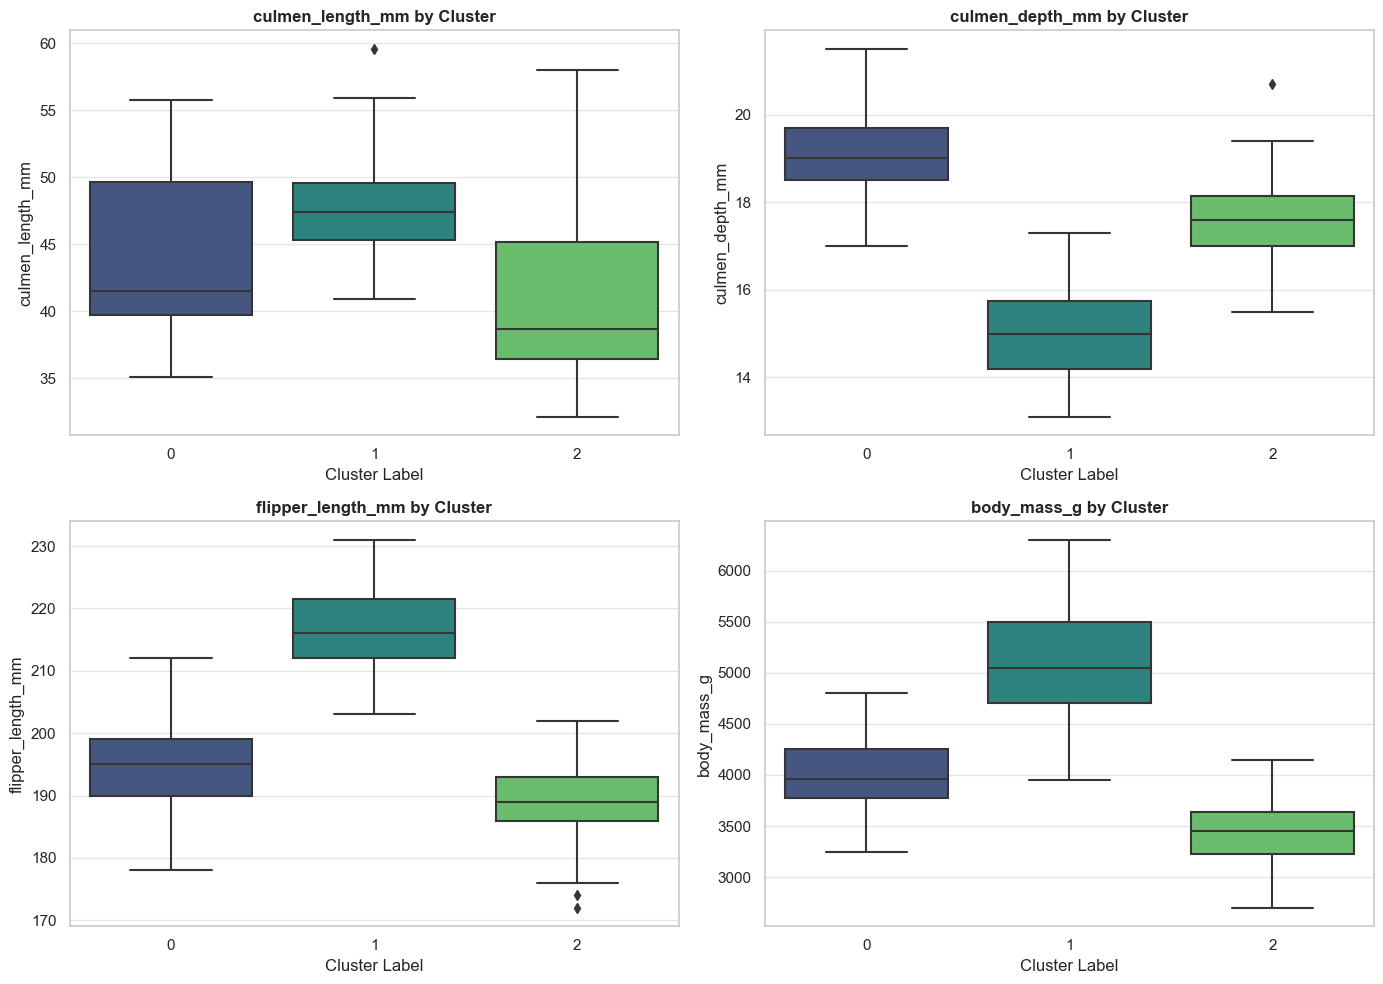

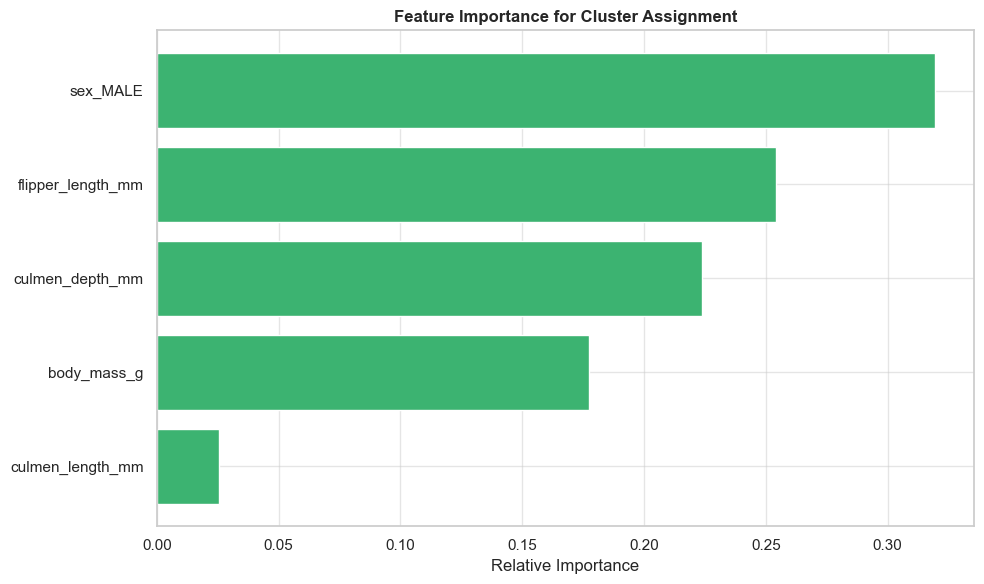

In [10]:
# Boxplots for numerical features per cluster
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=penguins_df, x='label', y=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} by Cluster', fontweight='bold')
    axes[i].set_xlabel('Cluster Label')

plt.tight_layout()
plt.show()

# Feature Importance via Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, penguins_df['label'])

importances = rf.feature_importances_
indices = np.argsort(importances)
features = penguins_dummies.columns

plt.figure(figsize=(10, 6))
plt.title('Feature Importance for Cluster Assignment', fontweight='bold')
plt.barh(range(len(indices)), importances[indices], color='mediumseagreen', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('../images/penguins_feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

Statistically validating the clustering and stability of the clusters

Running Statistical Validation...


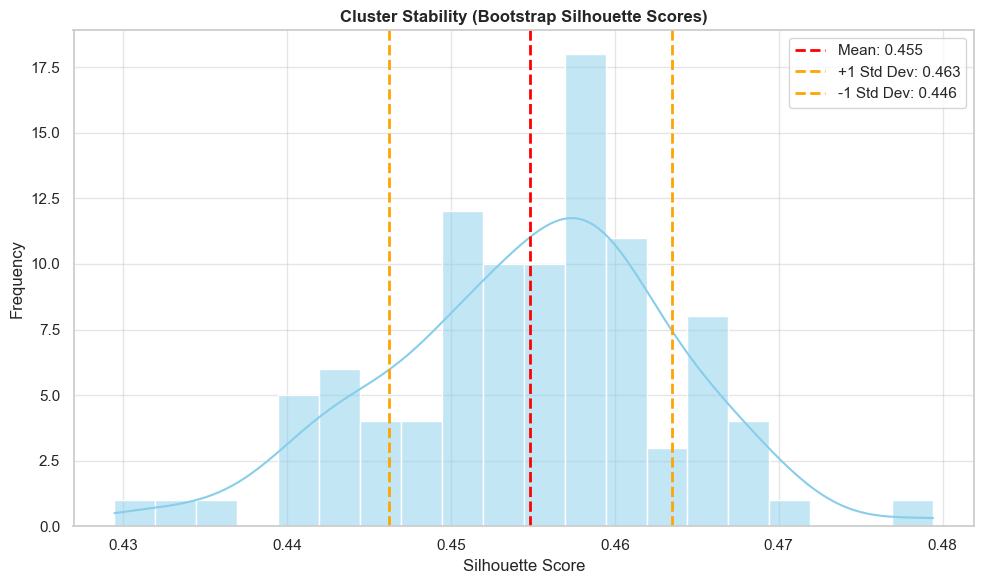


--- ANOVA Test Results (P-values) ---
culmen_length_mm: p-value = 3.36e-27
culmen_depth_mm: p-value = 1.93e-106
flipper_length_mm: p-value = 1.82e-108
body_mass_g: p-value = 3.11e-103


In [11]:
print("Running Statistical Validation...")

# 11.1 Cluster Stability (Bootstrapping)
n_iterations = 100
bootstrap_silhouette = []

for _ in range(n_iterations):
    X_resampled = resample(X_scaled, random_state=None)
    km_boot = KMeans(n_clusters=n_clusters, n_init=10).fit(X_resampled)
    score = silhouette_score(X_resampled, km_boot.labels_)
    bootstrap_silhouette.append(score)

mean_sil = np.mean(bootstrap_silhouette)
std_sil = np.std(bootstrap_silhouette)

plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_silhouette, kde=True, color='skyblue', bins=20)
plt.axvline(mean_sil, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_sil:.3f}')
plt.axvline(mean_sil + std_sil, color='orange', linestyle='dashed', linewidth=2, label=f'+1 Std Dev: {mean_sil+std_sil:.3f}')
plt.axvline(mean_sil - std_sil, color='orange', linestyle='dashed', linewidth=2, label=f'-1 Std Dev: {mean_sil-std_sil:.3f}')
plt.title('Cluster Stability (Bootstrap Silhouette Scores)', fontweight='bold')
plt.xlabel('Silhouette Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../images/penguins_cluster_stability.png', bbox_inches='tight', dpi=300)
plt.show()

# 11.2 ANOVA Test to prove features vary significantly by cluster
print("\n--- ANOVA Test Results (P-values) ---")
for col in numeric_cols:
    groups = [penguins_df[penguins_df['label'] == i][col].values for i in range(n_clusters)]
    stat, p_value = f_oneway(*groups)
    print(f"{col}: p-value = {p_value:.2e}")

Final output - as per the requirements of original question

In [12]:
# Filter original numerical columns and group by the predicted K-Means labels
stat_penguins = penguins_df[numeric_cols + ['label']].groupby('label').mean()

print("\n--- Final 'stat_penguins' DataFrame ---")
print(stat_penguins)


--- Final 'stat_penguins' DataFrame ---
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
label                                                                   
0             43.878302        19.111321         194.764151  4006.603774
1             47.568067        14.996639         217.235294  5092.436975
2             40.217757        17.611215         189.046729  3419.158879


Based on the information provided by Allison Horst, it can now be confidently said that there are in fact 3 species of penguins in the dataset.